# Synthetic KRR: dense solve / Richardson / preconditioned Richardson / EFGP

这个 notebook 针对下面的 synthetic regression：

- `x_i ~ Unif([0, 1]^d)`, `d in {1, 2, 3}`
- `f_*(x) = cos(2 pi <x, omega> + 1.3)`
- `y_i = f_*(x_i) + epsilon_i`, `epsilon_i ~ N(0, sigma^2)`

并且只使用 `gpu_benchmark_datasets.ipynb` 里给出的两个 kernel：

- `mat32_ls0.1`
- `gaussian_ls0.1`

输出 6 张图：

1. direct solve 下，求解时间 vs `N`（5 个点）
2. 最大 `N` 下，direct solve vs Richardson 耗时
3. 最大 `N` 下，`A = K + lambda I` 的 PSD 谱
4. 最大 `N` 下，Richardson vs preconditioned Richardson 耗时
5. 最大 `N` 下，`P A` 的 PSD 谱，并与 `A` 对比
6. 最大 `N` 下，dense Richardson vs EFGP 后的 Richardson：solve time / iteration 数 / iteration cost

说明：前 5 张图用的是 dense sample-space KRR；第 6 张图复用 `EFGPSolver` 做 EFGP 权重空间近似。为了让 `d=3` 的 EFGP 网格规模可运行，下面单独把 `EFGP_EPS` 设得比主 benchmark 更保守。

In [7]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def _resolve_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "efgp_eigenpro_py").exists():
            return candidate
    raise RuntimeError("Could not locate repo root containing 'efgp_eigenpro_py'.")


REPO_ROOT = _resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from efgp_eigenpro_py.efgp_solver import EFGPSolver
from efgp_eigenpro_py.eigenpro_precond import build_preconditioner
from efgp_eigenpro_py.eigenspace import estimate_top_eigenspace
from efgp_eigenpro_py.kernels import make_matern, make_squared_exponential
from efgp_eigenpro_py.linear_solvers import richardson

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: D:\NU\ML


In [8]:
KERNEL_SPECS = [
    {
        "name": "mat32_ls0.1",
        "family": "matern",
        "nu": 1.5,
        "lengthscale": 0.1,
        "variance": 1.0,
    },
    {
        "name": "gaussian_ls0.1",
        "family": "gaussian",
        "lengthscale": 0.1,
        "variance": 1.0,
    },
]

DIM_LIST = [3]
N_LIST = [384, 512, 640, 768, 896, 1024]
MAX_N = max(N_LIST)
NOISE_STD = 0.05
REG_LAMBDA = 0.1
DIRECT_REPEATS = 3
RICHARDSON_TOL = 1e-6
RICHARDSON_MAXITER = 5000
PRECOND_TOP_Q = 32

# EFGP 这里单独取更保守的 eps，这样 d=3 / Matern 的 M 不会过大。
EFGP_EPS = 1e-4
EFGP_NUFFT_TOL = 1e-10
EFGP_L2_SCALED = True
EFGP_LAMBDA_EST_METHOD = "subspace_iter"
EFGP_LAMBDA_EST_MAXITER = 4

GLOBAL_SEED = 20260511


def omega_for_dim(dim: int) -> np.ndarray:
    omega = np.arange(1, dim + 1, dtype=np.float64)
    omega /= np.linalg.norm(omega)
    return omega


def kernel_label(kernel_cfg: dict) -> str:
    family = str(kernel_cfg["family"]).strip().lower()
    if family == "matern":
        return f"Matern nu={kernel_cfg['nu']}, l={kernel_cfg['lengthscale']}"
    return f"Gaussian l={kernel_cfg['lengthscale']}"


print("DIM_LIST:", DIM_LIST)
print("N_LIST:", N_LIST)
print("REG_LAMBDA:", REG_LAMBDA)
print("EFGP_EPS:", EFGP_EPS)

DIM_LIST: [3]
N_LIST: [384, 512, 640, 768, 896, 1024]
REG_LAMBDA: 0.1
EFGP_EPS: 0.0001


In [9]:
def make_kernel_from_cfg(kernel_cfg: dict, dim: int):
    family = str(kernel_cfg.get("family", "matern")).strip().lower()
    lengthscale = float(kernel_cfg["lengthscale"])
    variance = float(kernel_cfg.get("variance", 1.0))
    if family in {"matern", "mat", "mat32", "mat52"}:
        nu = float(kernel_cfg.get("nu", 1.5))
        return make_matern(lengthscale=lengthscale, nu=nu, dim=int(dim), variance=variance)
    if family in {"gaussian", "rbf", "se", "squared_exponential", "squared-exponential"}:
        return make_squared_exponential(lengthscale=lengthscale, dim=int(dim), variance=variance)
    raise ValueError(f"Unsupported kernel family: {family}")


def target_function(x: np.ndarray, omega: np.ndarray, phase: float = 1.3) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    return np.cos(2.0 * np.pi * (x @ omega) + float(phase))


def generate_nested_dataset(dim: int, n_max: int, noise_std: float, seed: int) -> dict:
    rng = np.random.default_rng(int(seed))
    omega = omega_for_dim(dim)
    x_train = rng.uniform(0.0, 1.0, size=(int(n_max), int(dim)))
    y_true = target_function(x_train, omega)
    y_train = y_true + rng.normal(0.0, float(noise_std), size=int(n_max))
    return {
        "dim": int(dim),
        "omega": omega,
        "x_train": np.asarray(x_train, dtype=np.float64),
        "y_train": np.asarray(y_train, dtype=np.float64),
        "y_true": np.asarray(y_true, dtype=np.float64),
    }


def pairwise_distance_matrix(x1: np.ndarray, x2: np.ndarray | None = None) -> np.ndarray:
    x1 = np.asarray(x1, dtype=np.float64)
    x2 = x1 if x2 is None else np.asarray(x2, dtype=np.float64)
    diff = x1[:, None, :] - x2[None, :, :]
    return np.linalg.norm(diff, axis=-1)


def build_dense_krr_system(
    x_train: np.ndarray,
    y_train: np.ndarray,
    kernel_cfg: dict,
    reg_lambda: float,
) -> tuple[object, np.ndarray, np.ndarray, np.ndarray]:
    kernel = make_kernel_from_cfg(kernel_cfg, x_train.shape[1])
    K = np.asarray(kernel.k(pairwise_distance_matrix(x_train)), dtype=np.float64)
    A = K + float(reg_lambda) * np.eye(x_train.shape[0], dtype=np.float64)
    b = np.asarray(y_train, dtype=np.float64).reshape(-1)
    return kernel, K, A, b


def timed_direct_solve(A: np.ndarray, b: np.ndarray) -> dict:
    t0 = time.perf_counter()
    alpha = np.linalg.solve(A, b)
    t1 = time.perf_counter()
    relres = np.linalg.norm(A @ alpha - b) / max(np.linalg.norm(b), 1e-12)
    return {
        "alpha": alpha,
        "time_s": float(t1 - t0),
        "relres": float(relres),
    }


def richardson_eta_from_lambda_max(lambda_max: float, safety: float = 0.9) -> float:
    return float(safety) / max(float(lambda_max), 1e-12)


def run_dense_richardson_case(
    A: np.ndarray,
    b: np.ndarray,
    lambda_max_effective: float,
    *,
    precond=None,
) -> dict:
    eta = richardson_eta_from_lambda_max(lambda_max_effective)
    x0 = np.zeros_like(b)
    t0 = time.perf_counter()
    alpha, iters, relres = richardson(
        lambda v: A @ v,
        b,
        x0,
        eta=eta,
        tol=RICHARDSON_TOL,
        maxiter=RICHARDSON_MAXITER,
        precond=precond,
    )
    t1 = time.perf_counter()
    return {
        "alpha": alpha,
        "eta": float(eta),
        "iters": int(iters),
        "relres": float(relres),
        "time_s": float(t1 - t0),
    }


def build_dense_eigenpro_preconditioner(
    A: np.ndarray,
    eigvals_desc: np.ndarray,
    eigvecs_desc: np.ndarray,
    top_q: int,
) -> tuple[object, np.ndarray, np.ndarray, int]:
    n = int(eigvals_desc.size)
    q = max(1, min(int(top_q), n - 1))
    theta = np.asarray(eigvals_desc[:q], dtype=np.float64)
    U = np.asarray(eigvecs_desc[:, :q], dtype=np.float64)
    mu = float(eigvals_desc[q])
    precond = build_preconditioner(theta, U, mu)
    scale = 1.0 - (mu / theta)
    P = np.eye(n, dtype=np.float64) - U @ (scale[:, None] * U.T)
    PA_dense = 0.5 * ((P @ A) + (A @ P))
    pa_eigvals = np.linalg.eigvalsh(PA_dense)[::-1]
    return precond, P, np.asarray(pa_eigvals, dtype=np.float64), q


def estimate_efgp_lambda_max(solver: EFGPSolver, state) -> float:
    eigpairs = estimate_top_eigenspace(
        lambda v: solver._apply_A(state, v),
        size=int(state.rhs.size),
        top_q=1,
        method=EFGP_LAMBDA_EST_METHOD,
        maxiter=EFGP_LAMBDA_EST_MAXITER,
        matvec_block=lambda V: solver._apply_A_block(state, V),
        block_size=4,
        oversample=1,
    )
    return float(np.real(eigpairs.values[0]))


def run_efgp_richardson_case(x_train: np.ndarray, y_train: np.ndarray, kernel_cfg: dict) -> dict:
    kernel = make_kernel_from_cfg(kernel_cfg, x_train.shape[1])
    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=REG_LAMBDA,
        eps=EFGP_EPS,
        nufft_tol=EFGP_NUFFT_TOL,
        l2scaled=EFGP_L2_SCALED,
    )

    t0 = time.perf_counter()
    state = solver.precompute(x_train, y_train)
    t1 = time.perf_counter()

    lambda_max = estimate_efgp_lambda_max(solver, state)
    eta = richardson_eta_from_lambda_max(lambda_max)
    beta0 = np.zeros_like(state.rhs)

    t2 = time.perf_counter()
    beta, iters, relres = richardson(
        lambda v: solver._apply_A(state, v),
        state.rhs,
        beta0,
        eta=eta,
        tol=RICHARDSON_TOL,
        maxiter=RICHARDSON_MAXITER,
    )
    t3 = time.perf_counter()

    return {
        "beta": beta,
        "eta": float(eta),
        "iters": int(iters),
        "relres": float(relres),
        "lambda_max_est": float(lambda_max),
        "M": int(state.rhs.size),
        "mtot": int(state.grid.mtot),
        "time_precompute_s": float(t1 - t0),
        "time_lambda_est_s": float(t2 - t1),
        "time_solve_s": float(t3 - t2),
        "time_total_s": float(t3 - t0),
    }

In [ ]:
dataset_cache = {
    dim: generate_nested_dataset(dim, MAX_N, NOISE_STD, GLOBAL_SEED + dim)
    for dim in DIM_LIST
}

direct_rows: list[dict] = []
largest_rows: list[dict] = []
largest_case_cache: dict[tuple[int, str], dict] = {}

for dim in DIM_LIST:
    payload = dataset_cache[dim]
    for kernel_cfg in KERNEL_SPECS:
        kernel_name = kernel_cfg["name"]
        kernel_title = kernel_label(kernel_cfg)

        for n in N_LIST:
            print(f"[dense] d={dim} kernel={kernel_name} N={n}")
            x_train = payload["x_train"][:n]
            y_train = payload["y_train"][:n]
            _kernel, K, A, b = build_dense_krr_system(x_train, y_train, kernel_cfg, REG_LAMBDA)

            direct_runs = [timed_direct_solve(A, b) for _ in range(DIRECT_REPEATS)]
            direct_times = [row["time_s"] for row in direct_runs]
            direct_rows.append(
                {
                    "dim": int(dim),
                    "kernel_name": kernel_name,
                    "kernel_title": kernel_title,
                    "N": int(n),
                    "time_s": float(np.median(direct_times)),
                    "time_s_mean": float(np.mean(direct_times)),
                    "time_s_std": float(np.std(direct_times)),
                    "relres": float(np.median([row["relres"] for row in direct_runs])),
                }
            )

            if n != MAX_N:
                continue

            eigvals_asc, eigvecs_asc = np.linalg.eigh(A)
            order = np.argsort(eigvals_asc)[::-1]
            eigvals_desc = np.asarray(np.real(eigvals_asc[order]), dtype=np.float64)
            eigvecs_desc = np.asarray(np.real(eigvecs_asc[:, order]), dtype=np.float64)

            dense_direct = timed_direct_solve(A, b)
            dense_richardson = run_dense_richardson_case(
                A,
                b,
                lambda_max_effective=float(eigvals_desc[0]),
                precond=None,
            )
            dense_precond, P_dense, pa_eigvals_desc, q_used = build_dense_eigenpro_preconditioner(
                A,
                eigvals_desc,
                eigvecs_desc,
                PRECOND_TOP_Q,
            )
            dense_precond_richardson = run_dense_richardson_case(
                A,
                b,
                lambda_max_effective=float(pa_eigvals_desc[0]),
                precond=dense_precond.apply,
            )
            efgp_case = run_efgp_richardson_case(x_train, y_train, kernel_cfg)

            key = (int(dim), kernel_name)
            largest_case_cache[key] = {
                "dim": int(dim),
                "kernel_name": kernel_name,
                "kernel_title": kernel_title,
                "N": int(n),
                "A": A,
                "K": K,
                "A_eigvals": eigvals_desc,
                "P": P_dense,
                "PA_eigvals": pa_eigvals_desc,
                "dense_direct": dense_direct,
                "dense_richardson": dense_richardson,
                "dense_precond_richardson": dense_precond_richardson,
                "efgp_richardson": efgp_case,
                "precond_top_q": int(q_used),
            }
            dense_iter_cost = float(dense_richardson["time_s"]) / max(int(dense_richardson["iters"]), 1)
            efgp_iter_cost = float(efgp_case["time_solve_s"]) / max(int(efgp_case["iters"]), 1)
            largest_rows.append(
                {
                    "dim": int(dim),
                    "kernel_name": kernel_name,
                    "kernel_title": kernel_title,
                    "N": int(n),
                    "direct_s": float(dense_direct["time_s"]),
                    "richardson_s": float(dense_richardson["time_s"]),
                    "richardson_iters": int(dense_richardson["iters"]),
                    "richardson_iter_cost_s": dense_iter_cost,
                    "precond_richardson_s": float(dense_precond_richardson["time_s"]),
                    "efgp_richardson_solve_s": float(efgp_case["time_solve_s"]),
                    "efgp_richardson_iters": int(efgp_case["iters"]),
                    "efgp_richardson_iter_cost_s": efgp_iter_cost,
                    "efgp_precompute_s": float(efgp_case["time_precompute_s"]),
                    "efgp_lambda_est_s": float(efgp_case["time_lambda_est_s"]),
                    "efgp_total_s": float(efgp_case["time_total_s"]),
                    "efgp_M": int(efgp_case["M"]),
                    "efgp_mtot": int(efgp_case["mtot"]),
                }
            )

direct_df = pd.DataFrame(direct_rows).sort_values(["dim", "kernel_name", "N"]).reset_index(drop=True)
largest_df = pd.DataFrame(largest_rows).sort_values(["dim", "kernel_name"]).reset_index(drop=True)
dense_vs_efgp_df = largest_df[
    [
        "dim",
        "kernel_name",
        "N",
        "richardson_s",
        "richardson_iters",
        "richardson_iter_cost_s",
        "efgp_richardson_solve_s",
        "efgp_richardson_iters",
        "efgp_richardson_iter_cost_s",
        "efgp_precompute_s",
        "efgp_lambda_est_s",
        "efgp_total_s",
        "efgp_M",
        "efgp_mtot",
    ]
].copy()

print("\nDirect sweep summary:")
display(direct_df)
print("\nLargest-N summary:")
display(largest_df)
print("\nDense Richardson vs EFGP Richardson summary:")
display(dense_vs_efgp_df)

[dense] d=3 kernel=mat32_ls0.1 N=384
[dense] d=3 kernel=mat32_ls0.1 N=512
[dense] d=3 kernel=mat32_ls0.1 N=640
[dense] d=3 kernel=mat32_ls0.1 N=768
[dense] d=3 kernel=mat32_ls0.1 N=896
[dense] d=3 kernel=mat32_ls0.1 N=1024


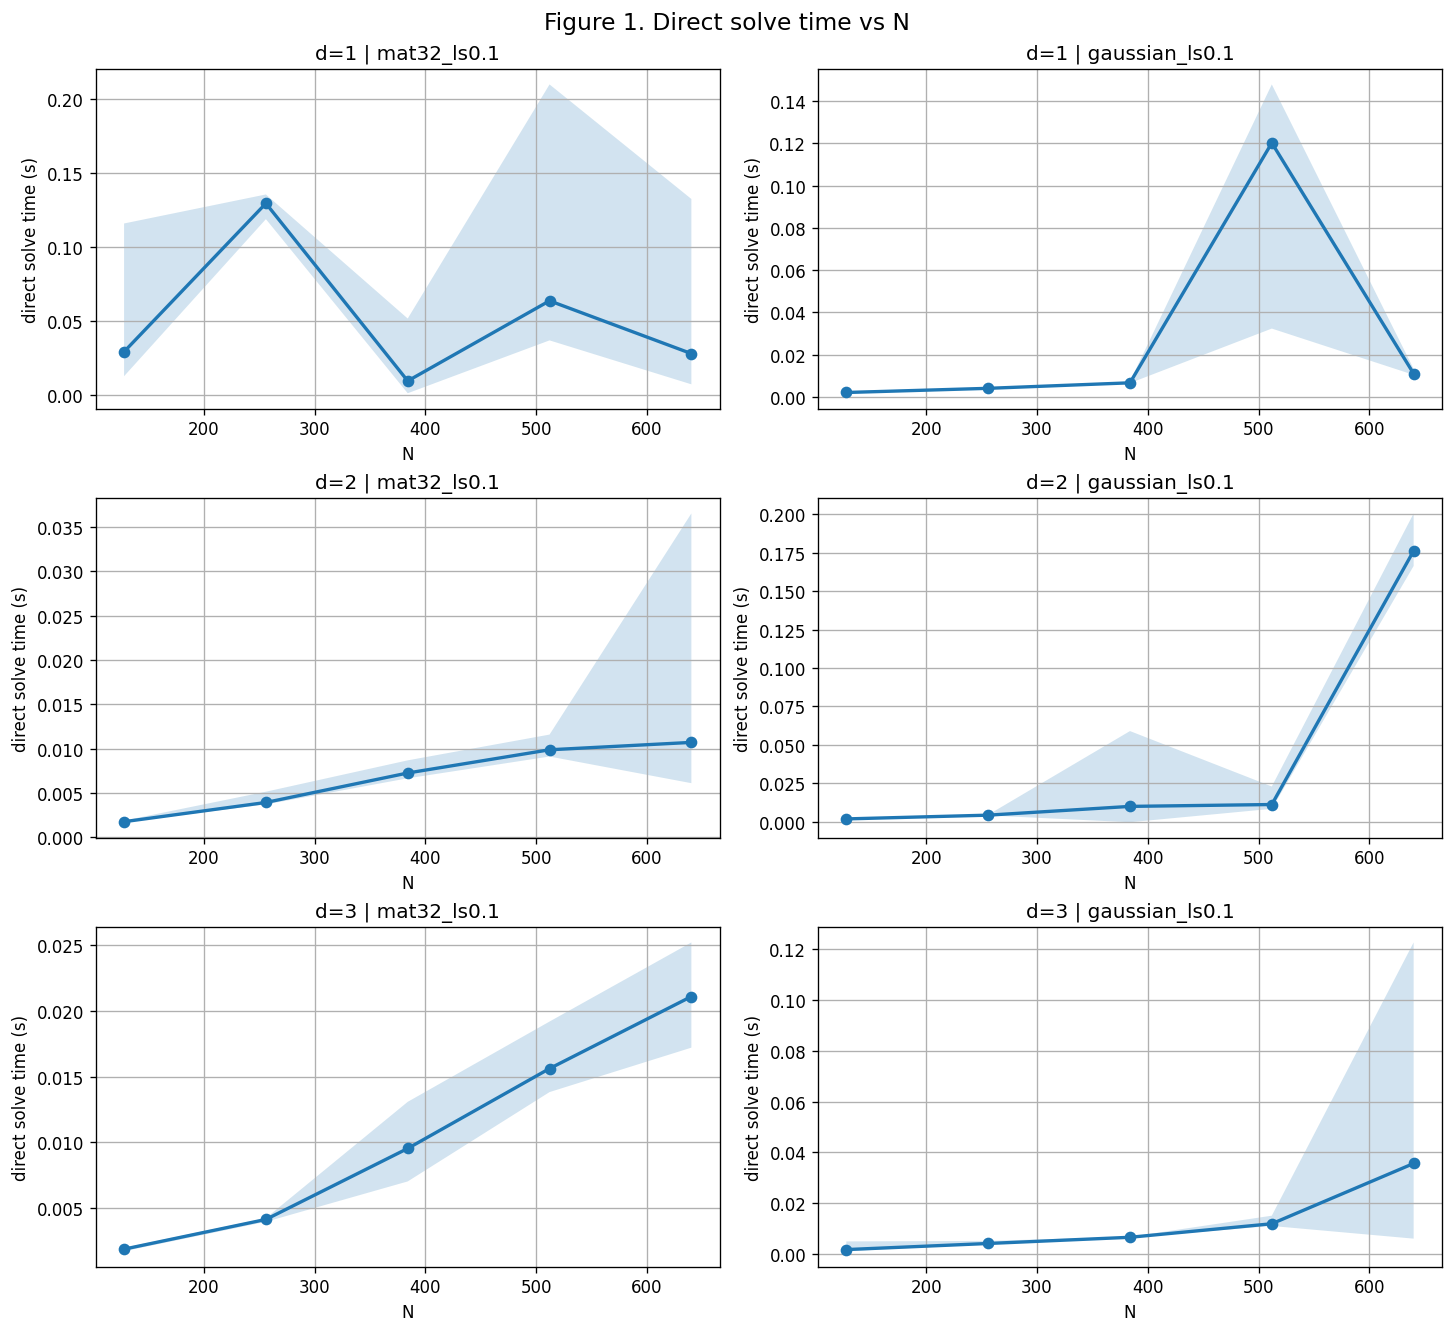

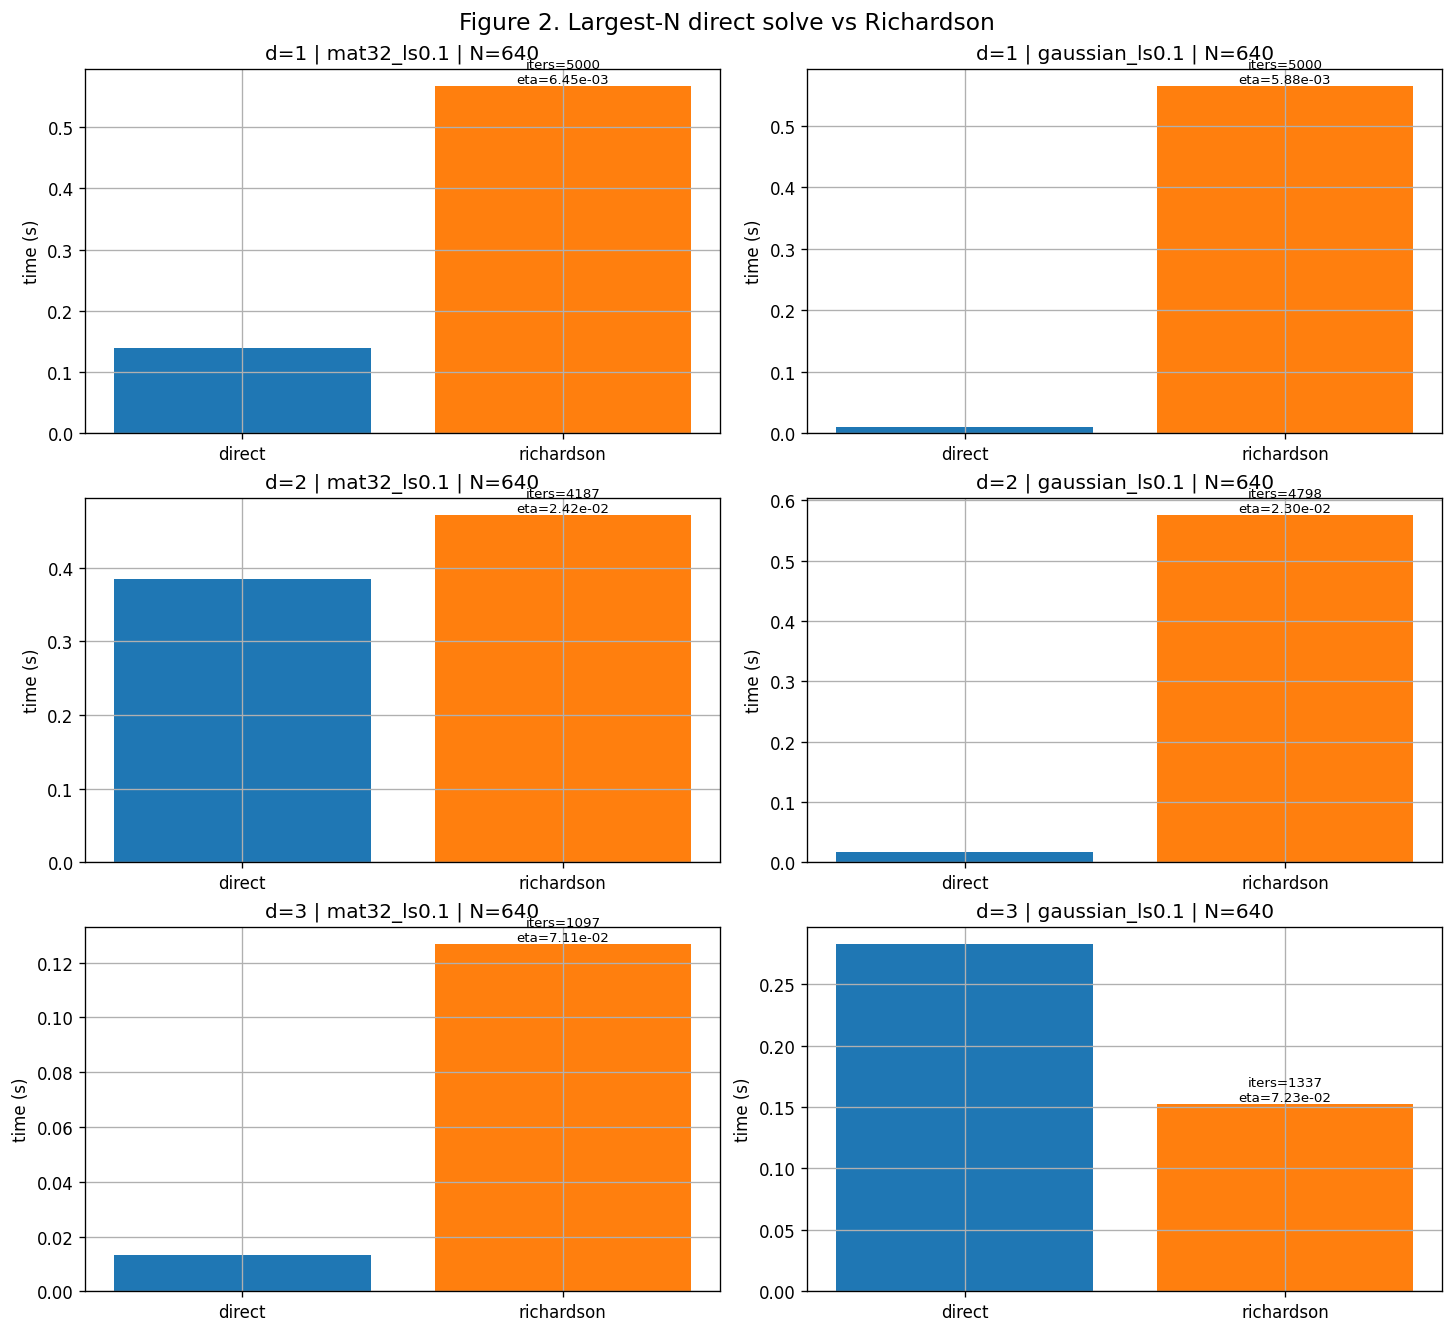

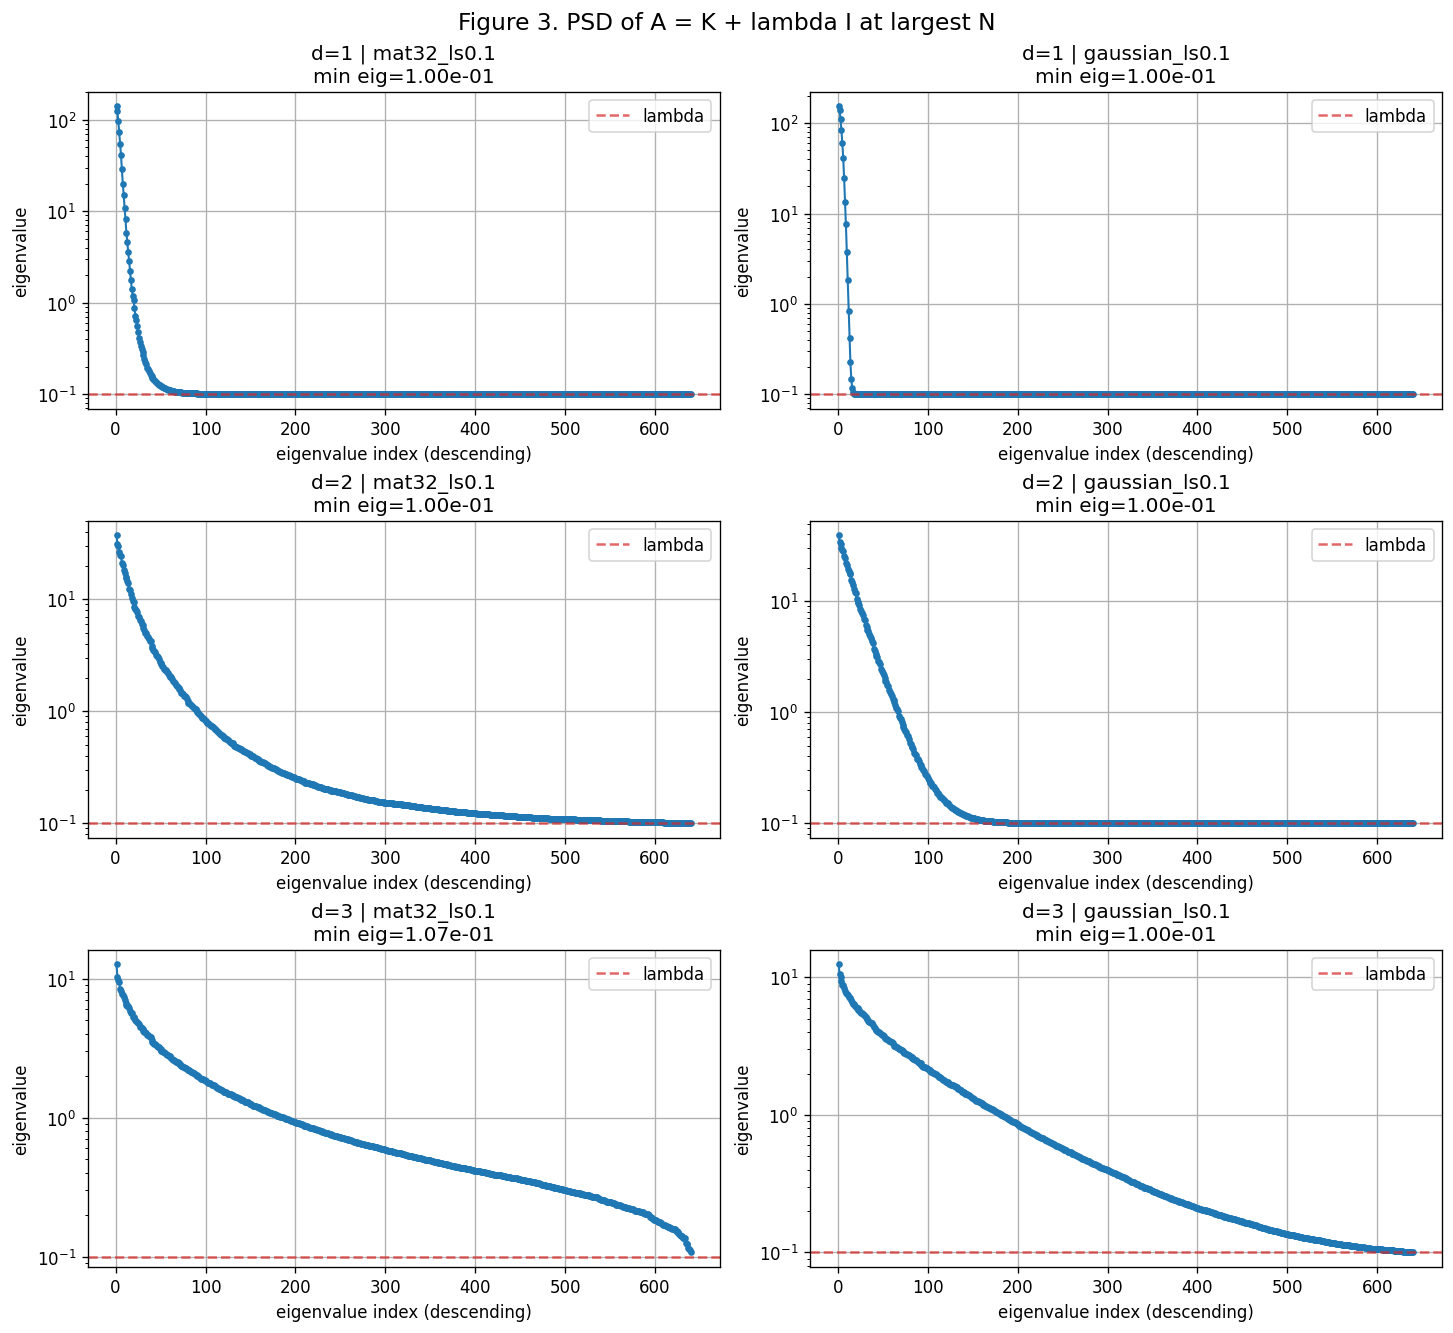

In [ ]:
fig, axes = plt.subplots(len(DIM_LIST), len(KERNEL_SPECS), figsize=(12, 11), constrained_layout=True)
for i, dim in enumerate(DIM_LIST):
    for j, kernel_cfg in enumerate(KERNEL_SPECS):
        ax = axes[i, j]
        subset = direct_df[
            (direct_df["dim"] == dim) & (direct_df["kernel_name"] == kernel_cfg["name"])
        ].sort_values("N")
        ax.plot(subset["N"], subset["time_s"], marker="o", linewidth=2)
        ax.fill_between(
            subset["N"],
            subset["time_s_mean"] - subset["time_s_std"],
            subset["time_s_mean"] + subset["time_s_std"],
            alpha=0.2,
        )
        ax.set_title(f"d={dim} | {kernel_cfg['name']}")
        ax.set_xlabel("N")
        ax.set_ylabel("direct solve time (s)")
fig.suptitle("Figure 1. Direct solve time vs N", fontsize=14)
plt.show()

fig, axes = plt.subplots(len(DIM_LIST), len(KERNEL_SPECS), figsize=(12, 11), constrained_layout=True)
for i, dim in enumerate(DIM_LIST):
    for j, kernel_cfg in enumerate(KERNEL_SPECS):
        ax = axes[i, j]
        case = largest_case_cache[(dim, kernel_cfg["name"])]
        labels = ["direct", "richardson"]
        values = [case["dense_direct"]["time_s"], case["dense_richardson"]["time_s"]]
        ax.bar(labels, values, color=["tab:blue", "tab:orange"])
        ax.set_title(f"d={dim} | {kernel_cfg['name']} | N={case['N']}")
        ax.set_ylabel("time (s)")
        ax.text(
            1,
            values[1],
            f"iters={case['dense_richardson']['iters']}\neta={case['dense_richardson']['eta']:.2e}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
fig.suptitle("Figure 2. Largest-N direct solve vs Richardson", fontsize=14)
plt.show()

fig, axes = plt.subplots(len(DIM_LIST), len(KERNEL_SPECS), figsize=(12, 11), constrained_layout=True)
for i, dim in enumerate(DIM_LIST):
    for j, kernel_cfg in enumerate(KERNEL_SPECS):
        ax = axes[i, j]
        case = largest_case_cache[(dim, kernel_cfg["name"])]
        eigvals = np.maximum(case["A_eigvals"], 1e-18)
        ax.semilogy(np.arange(1, eigvals.size + 1), eigvals, marker=".", linewidth=1.25)
        ax.axhline(REG_LAMBDA, linestyle="--", color="tab:red", alpha=0.7, label="lambda")
        ax.set_title(
            f"d={dim} | {kernel_cfg['name']}\nmin eig={case['A_eigvals'][-1]:.2e}"
        )
        ax.set_xlabel("eigenvalue index (descending)")
        ax.set_ylabel("eigenvalue")
        ax.legend(loc="best")
fig.suptitle("Figure 3. PSD of A = K + lambda I at largest N", fontsize=14)
plt.show()

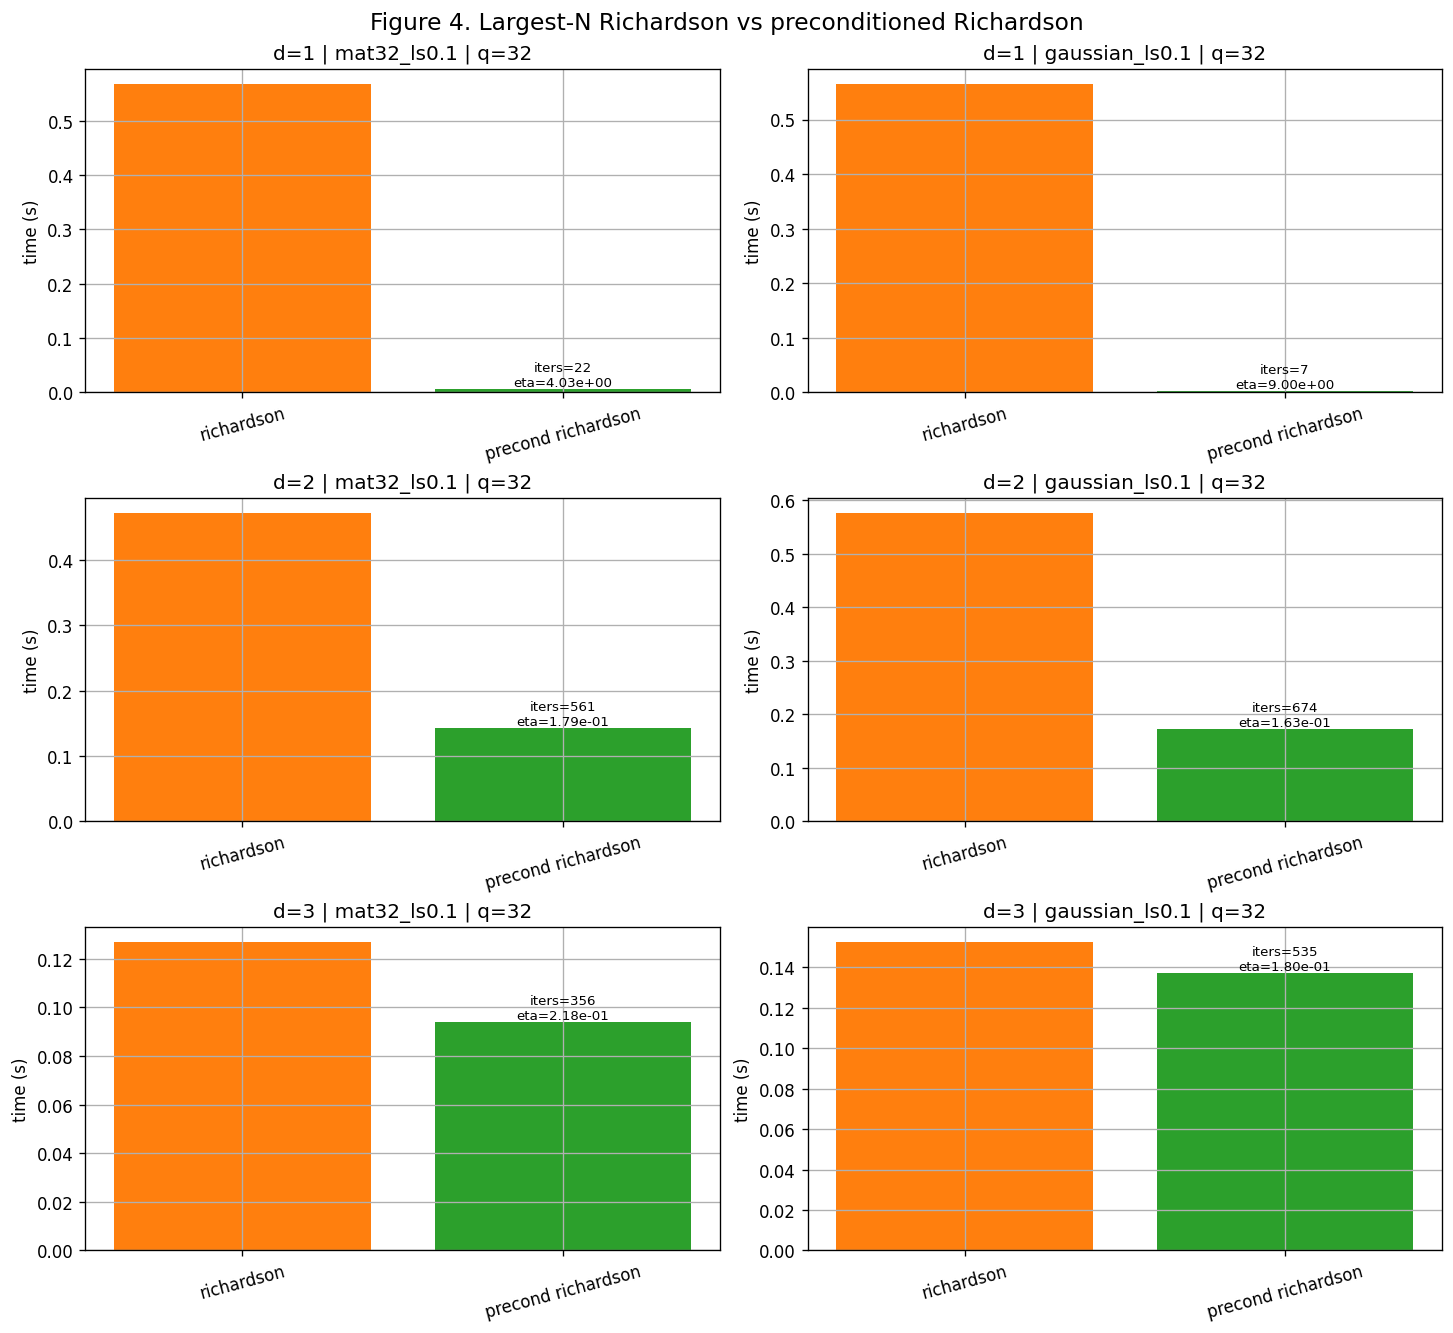

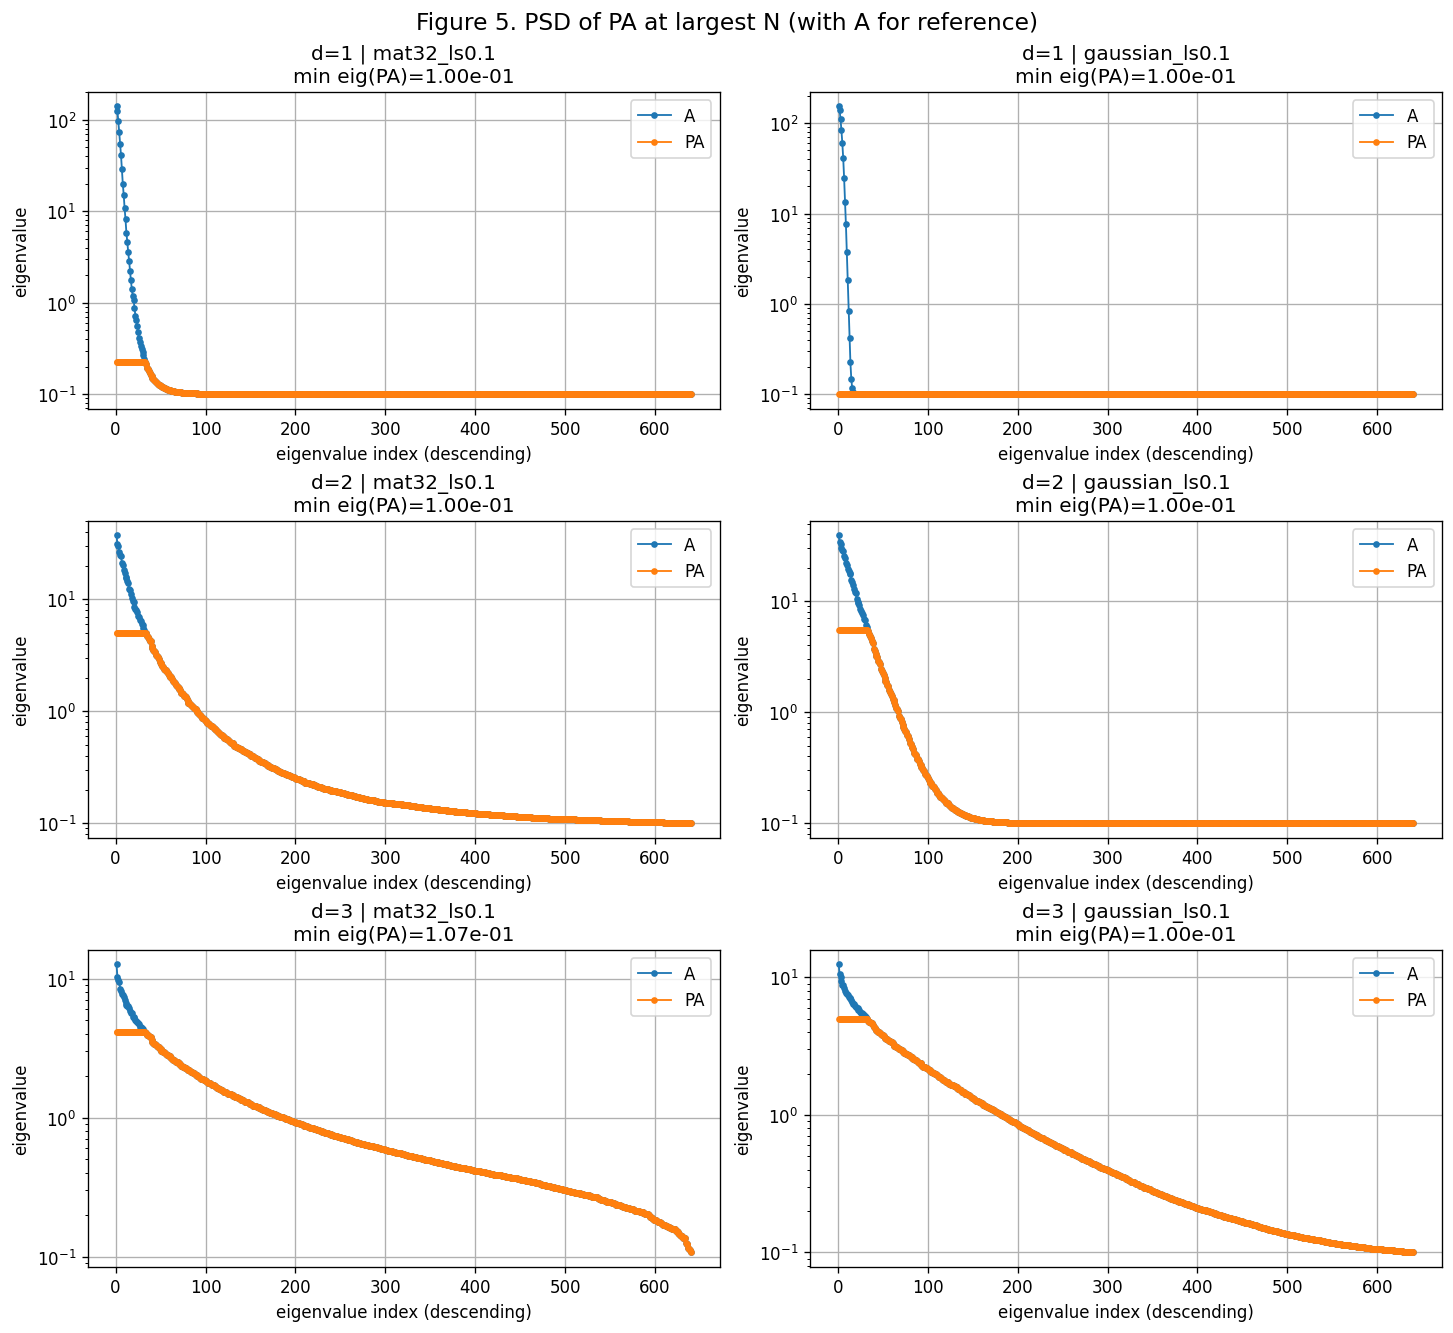

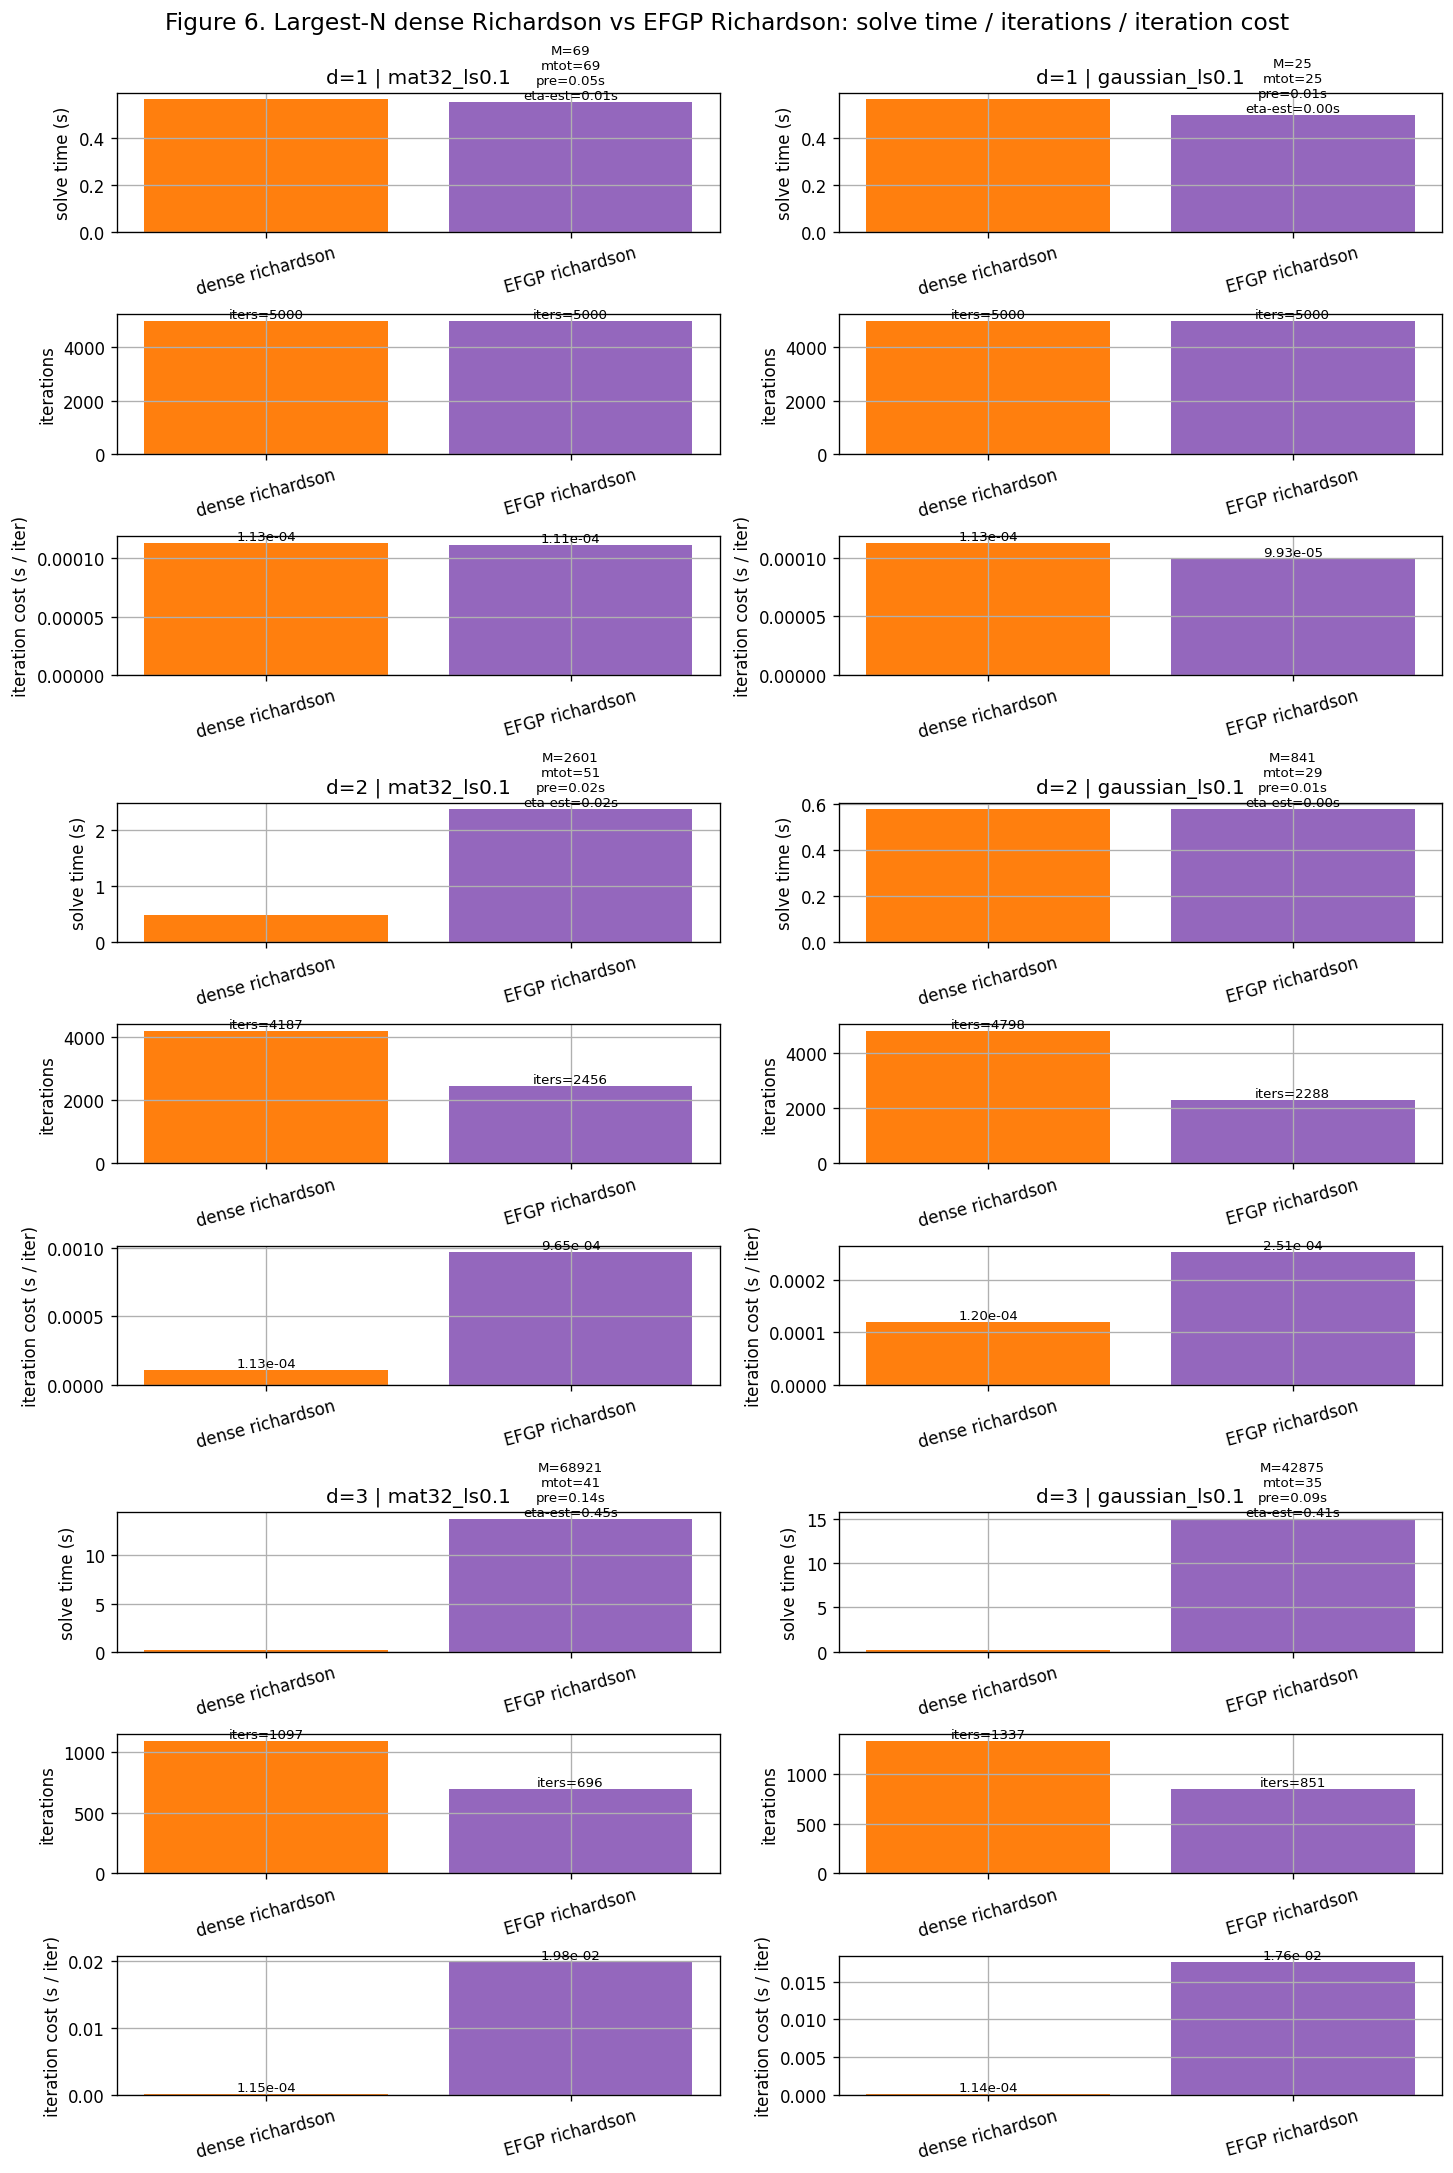

In [ ]:
fig, axes = plt.subplots(len(DIM_LIST), len(KERNEL_SPECS), figsize=(12, 11), constrained_layout=True)
for i, dim in enumerate(DIM_LIST):
    for j, kernel_cfg in enumerate(KERNEL_SPECS):
        ax = axes[i, j]
        case = largest_case_cache[(dim, kernel_cfg["name"])]
        labels = ["richardson", "precond richardson"]
        values = [
            case["dense_richardson"]["time_s"],
            case["dense_precond_richardson"]["time_s"],
        ]
        ax.bar(labels, values, color=["tab:orange", "tab:green"])
        ax.set_title(f"d={dim} | {kernel_cfg['name']} | q={case['precond_top_q']}")
        ax.set_ylabel("time (s)")
        ax.tick_params(axis="x", rotation=15)
        ax.text(
            1,
            values[1],
            f"iters={case['dense_precond_richardson']['iters']}\neta={case['dense_precond_richardson']['eta']:.2e}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
fig.suptitle("Figure 4. Largest-N Richardson vs preconditioned Richardson", fontsize=14)
plt.show()

fig, axes = plt.subplots(len(DIM_LIST), len(KERNEL_SPECS), figsize=(12, 11), constrained_layout=True)
for i, dim in enumerate(DIM_LIST):
    for j, kernel_cfg in enumerate(KERNEL_SPECS):
        ax = axes[i, j]
        case = largest_case_cache[(dim, kernel_cfg["name"])]
        a_eigs = np.maximum(case["A_eigvals"], 1e-18)
        pa_eigs = np.maximum(case["PA_eigvals"], 1e-18)
        ax.semilogy(np.arange(1, a_eigs.size + 1), a_eigs, marker=".", linewidth=1.1, label="A")
        ax.semilogy(np.arange(1, pa_eigs.size + 1), pa_eigs, marker=".", linewidth=1.1, label="PA")
        ax.set_title(
            f"d={dim} | {kernel_cfg['name']}\nmin eig(PA)={case['PA_eigvals'][-1]:.2e}"
        )
        ax.set_xlabel("eigenvalue index (descending)")
        ax.set_ylabel("eigenvalue")
        ax.legend(loc="best")
fig.suptitle("Figure 5. PSD of PA at largest N (with A for reference)", fontsize=14)
plt.show()

metric_specs = [
    ("solve time (s)", lambda case: [case["dense_richardson"]["time_s"], case["efgp_richardson"]["time_solve_s"]]),
    ("iterations", lambda case: [case["dense_richardson"]["iters"], case["efgp_richardson"]["iters"]]),
    (
        "iteration cost (s / iter)",
        lambda case: [
            case["dense_richardson"]["time_s"] / max(case["dense_richardson"]["iters"], 1),
            case["efgp_richardson"]["time_solve_s"] / max(case["efgp_richardson"]["iters"], 1),
        ],
    ),
]

fig, axes = plt.subplots(
    len(DIM_LIST) * len(metric_specs),
    len(KERNEL_SPECS),
    figsize=(12, 18),
    constrained_layout=True,
)

for i, dim in enumerate(DIM_LIST):
    for m_idx, (ylabel, metric_fn) in enumerate(metric_specs):
        row_idx = i * len(metric_specs) + m_idx
        for j, kernel_cfg in enumerate(KERNEL_SPECS):
            ax = axes[row_idx, j]
            case = largest_case_cache[(dim, kernel_cfg["name"])]
            labels = ["dense richardson", "EFGP richardson"]
            values = metric_fn(case)
            ax.bar(labels, values, color=["tab:orange", "tab:purple"])
            ax.set_ylabel(ylabel)
            ax.tick_params(axis="x", rotation=15)
            if m_idx == 0:
                ax.set_title(f"d={dim} | {kernel_cfg['name']}")
                ax.text(
                    1,
                    values[1],
                    (
                        f"M={case['efgp_richardson']['M']}\n"
                        f"mtot={case['efgp_richardson']['mtot']}\n"
                        f"pre={case['efgp_richardson']['time_precompute_s']:.2f}s\n"
                        f"eta-est={case['efgp_richardson']['time_lambda_est_s']:.2f}s"
                    ),
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
            elif m_idx == 1:
                ax.text(
                    0,
                    values[0],
                    f"iters={case['dense_richardson']['iters']}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
                ax.text(
                    1,
                    values[1],
                    f"iters={case['efgp_richardson']['iters']}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
            else:
                ax.text(
                    0,
                    values[0],
                    f"{values[0]:.2e}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
                ax.text(
                    1,
                    values[1],
                    f"{values[1]:.2e}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

fig.suptitle(
    "Figure 6. Largest-N dense Richardson vs EFGP Richardson: solve time / iterations / iteration cost",
    fontsize=14,
)
plt.show()